# Projeto Final de Machine Learning
## Gravidade de acidentes nas rodovias federais de Santa Catarina

Dados abertos da PRF, acidentes agrupados por ocorrência, Santa Catarina de 2021 a 2025.

| Item | Definição |
|---|---|
| Unidade de análise | Um acidente registrado pela PRF |
| Alvo (Y) | `grave`: 1 se houve vítima fatal, 0 caso contrário |
| Tarefa | Classificação binária |
| Métrica principal | Recall e F1 da classe grave |
| Restrição | Falso negativo é caro: deixar passar um acidente fatal |

As decisões de balanceamento seguem trabalhos com os mesmos dados da PRF, citados na seção 11.

Escolhemos SC porque a BR-101, que passa por Criciúma, é a rodovia com mais acidentes do país (CNT, 2026). Usamos 2021 a 2025 porque a PRF mudou o sistema de coleta em 2017, e 2026 ficou fora por estar incompleto.

A ideia inicial era prever a chance de alguém sofrer um acidente, mas o arquivo só tem acidentes que já aconteceram, sem registro de quem passou e não bateu. Então o que dá para prever é: dado que o acidente aconteceu, qual a chance de ter sido fatal.

## 1. Carga dos dados

Os CSVs da PRF usam ponto e vírgula como separador e precisam de `encoding='latin-1'` por causa dos acentos.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# no Colab os arquivos ficam em /content; local, na pasta dados/
PASTA = 'dados/' if os.path.isdir('dados') else '/content/'

dfs = []
for ano in [2021, 2022, 2023, 2024, 2025]:
    d = pd.read_csv(f'{PASTA}datatran{ano}.csv', sep=';', encoding='latin-1', low_memory=False)
    d['ano_arquivo'] = ano          # guarda a origem da linha para o split temporal
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
print("Brasil:", df.shape)

dados = df[df['uf'] == 'SC'].copy()
print("Santa Catarina:", dados.shape)

Brasil: (342624, 31)
Santa Catarina: (39849, 31)


## 2. Inspeção dos dados brutos

Antes de alterar qualquer coisa, verificar o que chegou. Nenhuma estatística é calculada aqui.

In [ ]:
print("Dimensão:", dados.shape)
print("Duplicatas exatas:", dados.duplicated().sum())
print("IDs repetidos:", dados['id'].duplicated().sum())

dados.info()
display(dados.head())

Dimensão: (39849, 31)
Duplicatas exatas: 0
IDs repetidos: 0
<class 'pandas.core.frame.DataFrame'>
Index: 39849 entries, 8 to 342622
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      39849 non-null  float64
 1   data_inversa            39849 non-null  object 
 2   dia_semana              39849 non-null  object 
 3   horario                 39849 non-null  object 
 4   uf                      39849 non-null  object 
 5   br                      39849 non-null  int64  
 6   km                      39849 non-null  object 
 7   municipio               39849 non-null  object 
 8   causa_acidente          39849 non-null  object 
 9   tipo_acidente           39849 non-null  object 
 10  classificacao_acidente  39849 non-null  object 
 11  fase_dia                39849 non-null  object 
 12  sentido_via             39849 non-null  object 
 13  condicao_metereologica  39849 non-n

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano_arquivo
8,331864.0,2021-01-01,sexta-feira,17:10:00,SC,470,"79,1",INDAIAL,Transitar na contramão,Colisão frontal,...,0,1,6,4,"-26,951565","-49,306534",SPRF-SC,DEL04-SC,UOP01-DEL04-SC,2021
10,331910.0,2021-01-01,sexta-feira,19:50:00,SC,470,130,LONTRAS,Acessar a via sem observar a presença dos outr...,Colisão transversal,...,2,1,2,3,"-27,16037609","-49,55657959",SPRF-SC,DEL04-SC,UOP02-DEL04-SC,2021
18,331979.0,2021-01-02,sábado,09:25:00,SC,101,112,ITAJAI,Trafegar com motocicleta (ou similar) entre as...,Colisão traseira,...,2,1,2,4,"-26,84589005","-48,72131295",SPRF-SC,DEL04-SC,UOP04-DEL04-SC,2021
36,332133.0,2021-01-03,domingo,00:40:00,SC,101,127,ITAJAI,Reação tardia ou ineficiente do condutor,Colisão lateral,...,1,1,1,2,"-26,9639319","-48,68328024",SPRF-SC,DEL04-SC,UOP04-DEL04-SC,2021
44,332193.0,2021-01-03,domingo,10:45:00,SC,470,104,APIUNA,Manobra de mudança de faixa,Colisão transversal,...,1,0,3,2,"-27,06135","-49,410408",SPRF-SC,DEL04-SC,UOP02-DEL04-SC,2021


In [ ]:
print(dados.isnull().sum())

print()
print("clima 'Ignorado':", (dados['condicao_metereologica'] == 'Ignorado').sum())
print("sentido 'Não Informado':", (dados['sentido_via'] == 'Não Informado').sum())
print("br igual a 0:", (dados['br'] == 0).sum())

           qtd   pct
regional     3  0.01
delegacia    8  0.02
uop         12  0.03

clima 'Ignorado': 341
sentido 'Não Informado': 44
br = 0 (não existe BR-0): 44


### Dicionário de dados

| Grupo | Colunas |
|---|---|
| Tempo | `data_inversa`, `dia_semana`, `horario` |
| Local | `uf`, `br`, `km`, `municipio`, `latitude`, `longitude` |
| Condições | `causa_acidente`, `tipo_acidente`, `fase_dia`, `sentido_via`, `condicao_metereologica`, `tipo_pista`, `tracado_via`, `uso_solo` |
| Desfecho | `classificacao_acidente`, `pessoas`, `mortos`, `feridos_leves`, `feridos_graves`, `feridos`, `ilesos`, `ignorados`, `veiculos` |
| Administrativas | `regional`, `delegacia`, `uop` |

Nenhuma duplicata. Só 23 valores ausentes, todos em colunas administrativas que não vão para o modelo. `km`, `latitude` e `longitude` vieram como texto por causa da vírgula decimal, e `br` veio como número mas é o nome da rodovia.

Três códigos representam ausência: `Ignorado` no clima (341), `Não Informado` no sentido da via (44) e `0` no `br` (44). Os dois últimos são as mesmas 44 linhas.

## 3. Higiene

Só correções de regra fixa, que não aprendem nada dos dados.

In [ ]:
# vírgula decimal -> ponto
dados['km'] = pd.to_numeric(dados['km'].astype(str).str.replace(',', '.'))
dados['latitude'] = pd.to_numeric(dados['latitude'].astype(str).str.replace(',', '.'))
dados['longitude'] = pd.to_numeric(dados['longitude'].astype(str).str.replace(',', '.'))

# br é o nome da rodovia, não quantidade. 0 não existe como rodovia.
dados['br'] = dados['br'].astype(str)
dados['br'] = dados['br'].replace('0', 'Desconhecido')

dados['condicao_metereologica'] = dados['condicao_metereologica'].replace('Ignorado', 'Desconhecido')
dados['sentido_via'] = dados['sentido_via'].replace('Não Informado', 'Desconhecido')

print(dados[['km', 'latitude', 'longitude']].dtypes)
print("Latitude vai de", dados['latitude'].min(), "até", dados['latitude'].max())

                             regra  linhas_afetadas
0   Vírgula decimal em km/lat/long            39849
1         br = 0 vira Desconhecido               44
2       Ignorado vira Desconhecido              341
3  Não Informado vira Desconhecido               44
4            Remoção de duplicatas                0

Faixa de latitude: -29.29864717 a -25.98133


| Regra | Linhas afetadas |
|---|---|
| Vírgula decimal virou ponto (km, latitude, longitude) | 39.849 |
| `br` = 0 virou Desconhecido | 44 |
| `Ignorado` no clima virou Desconhecido | 341 |
| `Não Informado` no sentido virou Desconhecido | 44 |
| Duplicatas removidas | 0 |

A latitude ficou entre -29,3 e -25,9, que é a faixa de Santa Catarina, então a conversão deu certo.

Os códigos de ausência viraram a categoria `Desconhecido` em vez de NaN. Pensamos em preencher o `br` pela moda, mas a moda é a BR-101, e isso inflaria justamente a rodovia central do trabalho.

## 4. Alvo e remoção de vazamento

`classificacao_acidente` tem três valores e virou binário: "Com Vítimas Fatais" = 1, o resto = 0.

| Erro | Por que é leakage | Correção |
|---|---|---|
| Manter `mortos`, `feridos_graves`, `feridos_leves`, `feridos`, `ilesos`, `ignorados` | São o desfecho do acidente, e é deles que sai o nosso alvo | Removidas do X |
| Ajustar scaler ou encoder antes do split | Os parâmetros incorporariam o teste | `fit` só no treino |
| Escolher categorias frequentes na base toda | A lista seria influenciada pelo teste | Aprendida só no treino |
| Olhar o teste para decidir transformações | O teste vira uma segunda validação | Teste usado uma vez só |

Também saem: `id`, `municipio` (127 categorias, muitas com pouquíssimos casos), `latitude` e `longitude` (coordenada com 8 casas decimais levaria o modelo a ter um Overfitting, o que não é o correto como ensinado na sala), as administrativas e `uf` (constante).

In [ ]:
dados['grave'] = (dados['classificacao_acidente'] == 'Com Vítimas Fatais').astype(int)

colunas_fora = [
    # vazamento: desfecho do acidente
    'classificacao_acidente', 'mortos', 'feridos_graves', 'feridos_leves',
    'feridos', 'ilesos', 'ignorados',
    # não descrevem o acidente
    'id', 'municipio', 'latitude', 'longitude',
    'regional', 'delegacia', 'uop', 'uf',
]

X = dados.drop(columns=['grave'] + colunas_fora)
y = dados['grave']

print("X:", X.shape)
print(X.columns.tolist())
print()
print(dados['classificacao_acidente'].value_counts())
print((dados['classificacao_acidente'].value_counts(normalize=True) * 100).round(2))

X: (39849, 16)
['data_inversa', 'dia_semana', 'horario', 'br', 'km', 'causa_acidente', 'tipo_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'veiculos', 'ano_arquivo']

classificacao_acidente
Com Vítimas Feridas    31996
Sem Vítimas             6179
Com Vítimas Fatais      1674
Name: count, dtype: int64
classificacao_acidente
Com Vítimas Feridas    80.29
Sem Vítimas            15.51
Com Vítimas Fatais      4.20
Name: proportion, dtype: float64


### O desbalanceamento e como ele é tratado

Só 4,2% dos acidentes são fatais: 1.674 de 39.849. No treino a proporção é de 4,11%, ou seja, **um acidente fatal para cada vinte e quatro comuns**.

Isso muda o trabalho inteiro. Um modelo que responda "não grave" em tudo acerta 95,9% e não encontra nenhum acidente fatal, que é justamente o que queremos achar. O baseline da seção 9 mostra isso na prática.

O problema é atacado em três frentes:

| Frente | O que faz | Onde aparece |
|---|---|---|
| Métricas | Revocação e F1 da classe grave no lugar da acurácia | Seções 9 e 12 |
| Peso de classe | `class_weight='balanced'` deixa o erro sobre um fatal 23 vezes mais caro | Modelo A, seção 11 |
| Reamostragem | Subamostragem descarta não graves; SMOTE cria fatais sintéticos | Modelo B, seção 11 |

A reamostragem entra **dentro do pipeline**, nunca na tabela inteira antes do treino. Se fosse aplicada antes, as partes de avaliação da validação cruzada teriam registros sintéticos ou perderiam registros reais. O teste de 2025 nunca é reamostrado e mantém a proporção real.

In [ ]:
# conferindo se o alvo bate com a coluna mortos
print(pd.crosstab(dados['grave'], dados['mortos'] > 0))

## 5. Split treino/teste

Antes de dividir, verificamos se a taxa de fatais muda com o tempo.

In [ ]:
taxa_ano = dados.groupby('ano_arquivo')['grave'].agg(['count', 'mean'])
taxa_ano['pct_grave'] = (taxa_ano['mean'] * 100).round(2)
print(taxa_ano[['count', 'pct_grave']])

             count  pct_grave
ano_arquivo                  
2021          7890       3.81
2022          7593       4.16
2023          7799       4.10
2024          8381       4.33
2025          8186       4.57


A taxa sobe de 3,81% em 2021 para 4,57% em 2025. Com essa tendência, um sorteio aleatório misturaria passado e futuro, então usamos split temporal: 2021 a 2024 para treino e 2025 para teste.

A validação é feita com K-Fold estratificado dentro do treino, em vez de separar mais um pedaço. Assim nenhum dos 1.300 acidentes fatais do treino fica de fora do aprendizado.

In [ ]:
# acidentes por mês, só pra ver se tem sazonalidade
print(pd.to_datetime(dados['data_inversa']).dt.month.value_counts().sort_index())

In [ ]:
X_train = X[dados['ano_arquivo'] < 2025].copy()
X_test = X[dados['ano_arquivo'] == 2025].copy()
y_train = y[dados['ano_arquivo'] < 2025].copy()
y_test = y[dados['ano_arquivo'] == 2025].copy()

print("Treino:", X_train.shape, "| % grave:", round(y_train.mean() * 100, 2))
print("Teste:", X_test.shape, "| % grave:", round(y_test.mean() * 100, 2))

Treino: (31663, 16) | grave: 4.11 %
Teste:  (8186, 16) | grave: 4.57 %


## 6. Checagem de esquema

Regras fixas de valores impossíveis, aplicadas nos dois conjuntos. As linhas que violam vão para quarentena em vez de serem apagadas.

In [ ]:
# valores impossíveis
regra_treino = ((X_train['km'] < 0) | (X_train['km'] > 1000) |
                (X_train['veiculos'] < 1) | (X_train['pessoas'] < 1))
regra_teste = ((X_test['km'] < 0) | (X_test['km'] > 1000) |
               (X_test['veiculos'] < 1) | (X_test['pessoas'] < 1))

print("Linhas que violam as regras no treino:", regra_treino.sum())
print("Linhas que violam as regras no teste:", regra_teste.sum())

# quarentena: guarda em vez de apagar
quarentena_treino = X_train[regra_treino]
quarentena_teste = X_test[regra_teste]

# mesmo filtro no y, senão as linhas desalinham
X_train = X_train[~regra_treino]
y_train = y_train[~regra_treino]
X_test = X_test[~regra_teste]
y_test = y_test[~regra_teste]

Quarentena no treino: 0
Quarentena no teste: 0

Casos de pessoas < veiculos: 736


Nenhuma linha violou as regras, então a quarentena ficou vazia.

## 7. Análise exploratória (somente no treino)

In [ ]:
treino = X_train.copy()
treino['grave'] = y_train

print("Valores ausentes no treino:", treino.isnull().sum().sum())
print()
print(treino[['km', 'pessoas', 'veiculos']].describe().round(2))

Valores ausentes no treino: 0

             km   pessoas  veiculos
count  31663.00  31663.00  31663.00
mean     176.25      2.43      1.97
std      136.60      1.57      0.94
min        0.00      1.00      1.00
25%       70.00      2.00      1.00
50%      142.30      2.00      2.00
75%      219.10      3.00      2.00
max      680.30     53.00     14.00


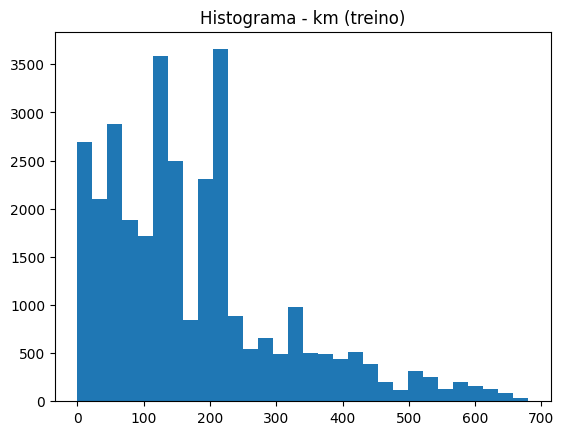

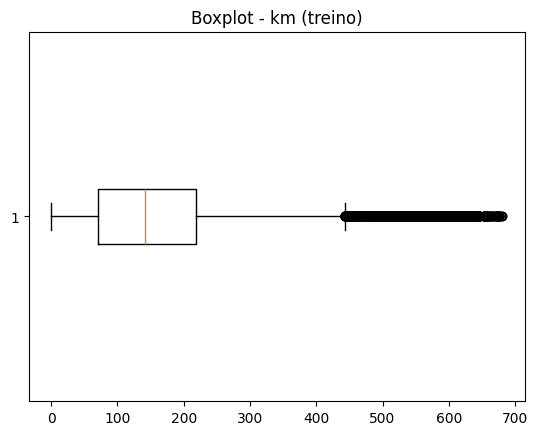

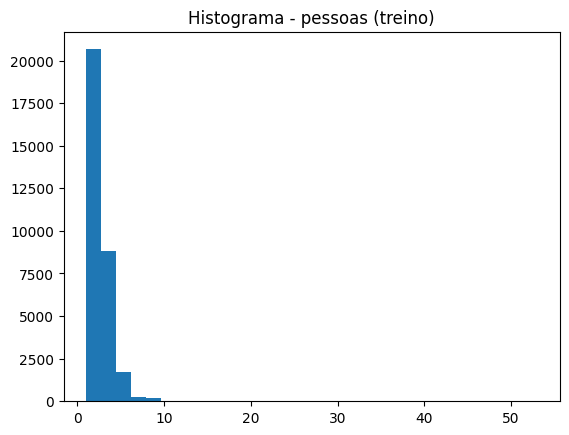

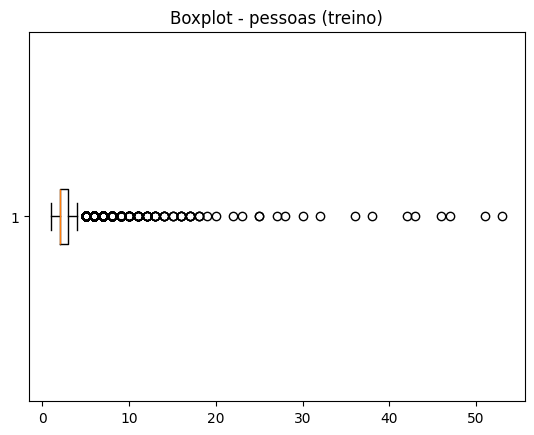

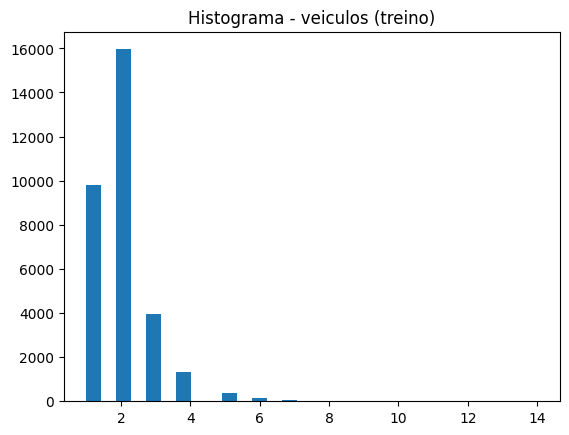

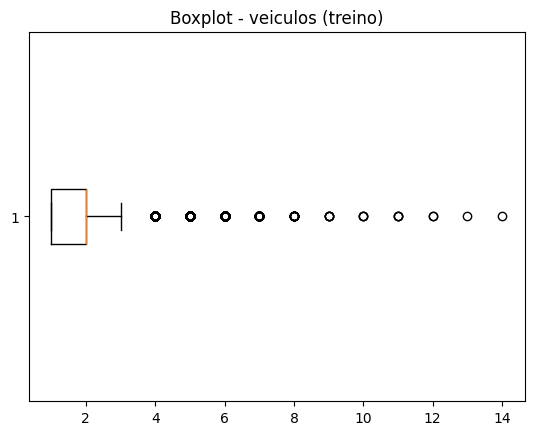

In [ ]:
for col in ['km', 'pessoas', 'veiculos']:
    plt.figure()
    plt.hist(treino[col], bins=30)
    plt.title(f'Histograma - {col} (treino)')
    plt.show()

    plt.figure()
    plt.boxplot(treino[col], vert=False)
    plt.title(f'Boxplot - {col} (treino)')
    plt.show()

In [ ]:
# IQR, limites calculados só no treino
for col in ['km', 'pessoas', 'veiculos']:
    q1 = treino[col].quantile(0.25)
    q3 = treino[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    extremos = (treino[col] < limite_inferior) | (treino[col] > limite_superior)

    print(col, "- extremos:", extremos.sum())
    print("   % grave nos extremos:", round(treino[extremos]['grave'].mean() * 100, 2))
    print("   % grave nos demais:", round(treino[~extremos]['grave'].mean() * 100, 2))

km: limites=[-153.6, 442.8] | extremos=1766
   grave nos extremos: 6.46% | nos demais: 3.97%
pessoas: limites=[0.5, 4.5] | extremos=2192
   grave nos extremos: 13.37% | nos demais: 3.42%
veiculos: limites=[-0.5, 3.5] | extremos=1938
   grave nos extremos: 12.44% | nos demais: 3.56%


In [ ]:
print(treino[['km', 'pessoas', 'veiculos', 'grave']].corr().round(3))

             km  pessoas  veiculos  grave
km        1.000    0.010    -0.052  0.030
pessoas   0.010    1.000     0.597  0.160
veiculos -0.052    0.597     1.000  0.152
grave     0.030    0.160     0.152  1.000


In [ ]:
for col in ['tipo_acidente', 'uso_solo', 'tipo_pista', 'fase_dia',
            'condicao_metereologica', 'sentido_via', 'dia_semana']:
    t = treino.groupby(col)['grave'].agg(['count', 'mean'])
    t['pct_grave'] = (t['mean'] * 100).round(2)
    print(f"--- {col} ---")
    print(t[['count', 'pct_grave']].sort_values('pct_grave', ascending=False))
    print()

# quantas categorias tem cada uma
for col in ['causa_acidente', 'tracado_via', 'tipo_acidente', 'br']:
    print(f"{col}: {treino[col].nunique()} categorias")

--- tipo_acidente ---
                                count  pct_grave
tipo_acidente                                   
Atropelamento de Pedestre         924      26.30
Colisão frontal                  2108      19.54
Eventos atípicos                   79       6.33
Colisão lateral sentido oposto    782       4.86
Atropelamento de Animal           165       3.03
Colisão com objeto               2637       3.00
Saída de leito carroçável        4208       2.97
Tombamento                       2600       2.69
Colisão traseira                 6478       2.19
Derramamento de carga              53       1.89
Colisão transversal              5006       1.82
Colisão lateral                   111       1.80
Engavetamento                     517       1.55
Colisão lateral mesmo sentido    4011       1.45
Queda de ocupante de veículo     1014       1.28
Capotamento                       593       1.18
Incêndio                          377       0.27

--- uso_solo ---
          count  pct_grave
us

In [ ]:
# curiosidade: onde acontece mais acidente em SC
print(dados['municipio'].value_counts().head(10))
print()
print(dados['br'].value_counts().head(8))

### O que a EDA mostrou

- **Tipo de acidente é o fator mais forte:** atropelamento 26,30% e colisão frontal 19,54% de gravidade, contra média de 4,11%.
- **Rural é quase o dobro:** 5,42% contra 2,79% urbano.
- **Pista simples:** 5,15% contra 2,49% na dupla.
- **Noite:** 5,83% contra 2,92% de dia.
- **Categorias raras enganam:** `Vento` tem 25% de gravidade, mas são só 8 casos.
- **Extremos de `pessoas` e `veiculos` importam:** têm 13,37% e 12,44% de gravidade contra 3,42% e 3,56% dos demais. São ônibus e engavetamentos.
- **Extremos de `km` não são erro:** cada BR começa do km 0, então juntar 12 rodovias cria vários picos.
- **Sentido da via e dia da semana** mudam pouco a taxa.

### Plano de ação

| Achado | Decisão |
|---|---|
| Zero valores ausentes | Sem imputação |
| Extremos concentram casos graves | Manter e usar RobustScaler |
| Desbalanceamento de 4,11% | Recall, F1 e `class_weight='balanced'` |
| `causa_acidente` com 74 categorias | Manter as 15 mais frequentes |
| `tracado_via` com 439 categorias | Manter as 10 mais frequentes |
| `Vento` e `Neve` com poucos casos | Agrupar |
| `horario` e `data_inversa` como texto | Extrair hora e mês |

### Checklist

| Pergunta | Resposta |
|---|---|
| O que entrou? | `X_train`, 31.663 linhas |
| O que aprendeu? | Quartis e taxas, só para decidir |
| Onde ocorreu fit? | Em lugar nenhum |
| Erro a evitar | Usar o teste para decidir |

## 8. Pré-processamento e features

Três features novas:
- `hora`, extraída do horário
- `mes`, extraído da data
- `ocupacao` = `pessoas / veiculos`. Um engavetamento de 8 carros e uma van com 8 passageiros têm as mesmas 8 pessoas, mas ocupação bem diferente.

O `ano_arquivo` sai aqui, porque só serviu para o split.

In [ ]:
def preparar(base):
    base = base.copy()
    base['hora'] = base['horario'].str.slice(0, 2).astype(int)    # "23:40:00" -> 23
    base['mes'] = pd.to_datetime(base['data_inversa']).dt.month
    base['ocupacao'] = base['pessoas'] / base['veiculos']
    base = base.drop(columns=['horario', 'data_inversa', 'ano_arquivo'])
    return base

X_train = preparar(X_train)
X_test = preparar(X_test)

# as mais frequentes, contadas SÓ no treino
top_causas = X_train['causa_acidente'].value_counts().head(15).index
top_tracado = X_train['tracado_via'].value_counts().head(10).index

# where: mantém se está na lista, senão troca
X_train['causa_acidente'] = X_train['causa_acidente'].where(X_train['causa_acidente'].isin(top_causas), 'Outras causas')
X_test['causa_acidente'] = X_test['causa_acidente'].where(X_test['causa_acidente'].isin(top_causas), 'Outras causas')

X_train['tracado_via'] = X_train['tracado_via'].where(X_train['tracado_via'].isin(top_tracado), 'Outros traçados')
X_test['tracado_via'] = X_test['tracado_via'].where(X_test['tracado_via'].isin(top_tracado), 'Outros traçados')

# Vento (8) e Neve (1): poucos casos
X_train['condicao_metereologica'] = X_train['condicao_metereologica'].replace(['Vento', 'Neve'], 'Outras condições')
X_test['condicao_metereologica'] = X_test['condicao_metereologica'].replace(['Vento', 'Neve'], 'Outras condições')

print(X_train.shape)

(31663, 16)
causas: 16 | traçados: 11


In [ ]:
# ocupacao nasceu agora, passa pelo mesmo teste
q1 = X_train['ocupacao'].quantile(0.25)
q3 = X_train['ocupacao'].quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
extremos = (X_train['ocupacao'] < limite_inferior) | (X_train['ocupacao'] > limite_superior)

print("Extremos de ocupacao:", extremos.sum())
print("% grave nos extremos:", round(y_train[extremos].mean() * 100, 2))
print("% grave nos demais:", round(y_train[~extremos].mean() * 100, 2))

ocupacao: min=0.15 max=53.00
  limites=[0.25, 2.25] | extremos=1505
  grave nos extremos: 8.77%
  grave nos demais:   3.87%


A `ocupacao` foi criada depois da EDA, então passou pelo mesmo diagnóstico. Tem 1.505 extremos, com 8,77% de gravidade contra 3,87% dos demais. Mantivemos pelo mesmo motivo de `pessoas` e `veiculos`.

In [ ]:
numericas = ['km', 'pessoas', 'veiculos', 'ocupacao', 'hora', 'mes']
print(X_train[numericas].corr().round(2))

            km  pessoas  veiculos  ocupacao  hora   mes
km        1.00     0.01     -0.05      0.06 -0.02 -0.00
pessoas   0.01     1.00      0.60      0.63  0.05 -0.00
veiculos -0.05     0.60      1.00     -0.12  0.08  0.00
ocupacao  0.06     0.63     -0.12      1.00 -0.01 -0.01
hora     -0.02     0.05      0.08     -0.01  1.00 -0.01
mes      -0.00    -0.00      0.00     -0.01 -0.01  1.00


`pessoas` e `veiculos` têm correlação de 0,60, e `pessoas` e `ocupacao` de 0,63, o que era esperado. Mantivemos as três porque medem coisas diferentes.

Nenhuma categórica virou ordinal: pista simples, dupla e múltipla não formam sequência na taxa de gravidade (5,15%, 2,49% e 4,36%).

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

categoricas = ['br', 'causa_acidente', 'tipo_acidente', 'fase_dia', 'sentido_via',
               'condicao_metereologica', 'tipo_pista', 'uso_solo', 'dia_semana', 'tracado_via']

preprocessador = ColumnTransformer([
    ('num', RobustScaler(), numericas),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categoricas),
])

# fit SÓ no treino
X_train_proc = preprocessador.fit_transform(X_train)
X_test_proc = preprocessador.transform(X_test)

print("Treino:", X_train_proc.shape)
print("Teste:", X_test_proc.shape)

# o que o scaler aprendeu
scaler = preprocessador.named_transformers_['num']
print("Colunas: ", numericas)
print("Medianas:", scaler.center_)
print("IQRs:    ", scaler.scale_)

Todas as colunas declaradas? True
Treino: (31663, 89) | Teste: (8186, 89)
  km: mediana=142.3 | IQR=149.1
  pessoas: mediana=2.0 | IQR=1.0
  veiculos: mediana=2.0 | IQR=1.0
  ocupacao: mediana=1.0 | IQR=0.5
  hora: mediana=14.0 | IQR=10.0
  mes: mediana=7.0 | IQR=6.0


Usamos `RobustScaler` porque ele trabalha com mediana e IQR, que não são afetados pelos extremos que decidimos manter. O `handle_unknown='ignore'` evita erro se 2025 tiver alguma categoria que não apareceu no treino.

O `fit` rodou uma vez, só no treino.

### Checklist

| Pergunta | Resposta |
|---|---|
| O que entrou? | `X_train` e `X_test` |
| O que aprendeu? | Mediana, IQR e lista de categorias |
| Onde ocorreu fit? | Só em `X_train` |
| Erro a evitar | Chamar `fit_transform` no teste |

## 9. Baseline

Teste para ver se o pipeline funciona e se existe sinal nos dados. Comparamos com um modelo que sempre responde "não grave".

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# 5 partes mantendo a proporção de graves
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# responde sempre "não grave"
baseline = Pipeline([('pre', preprocessador),
                     ('modelo', DummyClassifier(strategy='most_frequent'))])
resultado_base = cross_validate(baseline, X_train, y_train, cv=cv, scoring=metricas)

logistica = Pipeline([('pre', preprocessador),
                      ('modelo', LogisticRegression(max_iter=2000, class_weight='balanced'))])
resultado_log = cross_validate(logistica, X_train, y_train, cv=cv, scoring=metricas)

# o cross_validate põe "test_" na frente de cada métrica
print("Métrica    | Baseline | Logística")
for m in metricas:
    print(m, "|", round(resultado_base['test_' + m].mean(), 3), "|", round(resultado_log['test_' + m].mean(), 3))

--- Baseline trivial ---
  accuracy   0.959
  precision  0.000
  recall     0.000
  f1         0.000
  roc_auc    0.500

--- Regressão Logística ---
  accuracy   0.815
  precision  0.150
  recall     0.749
  f1         0.250
  roc_auc    0.863



### Resultado

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Baseline trivial | 0,959 | 0,000 | 0,000 | 0,000 | 0,500 |
| Regressão Logística | 0,815 | 0,150 | 0,749 | 0,250 | 0,863 |

O baseline tem accuracy **maior** e não encontra nenhum acidente fatal. Essa é a prova de que Accuracy não serve aqui.

A Regressão Logística acha 3 em cada 4 acidentes fatais. A precision é baixa porque o `class_weight` faz o modelo sinalizar mais, e preferimos isso a deixar passar casos graves.

**Métrica principal: Recall.** O erro mais grave neste problema é o falso negativo (FN): um acidente fatal que o modelo classifica como não grave. Por isso o que mais importa é quantos fatais ele encontra.

**Métrica de controle: Precision.** O Recall pode subir com o modelo acusando quase todos os acidentes. A Precision mostra o custo disso, que são os falsos positivos (FP), e impede uma conclusão enganosa.

### Checklist

| Pergunta | Resposta |
|---|---|
| O que entrou? | `X_train` |
| Onde ocorreu fit? | Dentro de cada divisão da validação cruzada |
| Erro a evitar | Pré-processar fora do pipeline |

## 10. Resumo da preparação

Partimos de 39.849 acidentes e 31 colunas e chegamos a 16 features, que viram 89 colunas depois da codificação. O baseline mostrou que existe sinal nos dados. Nas próximas seções treinamos os dois modelos e avaliamos no teste.

## 11. Modelos A e B

**Modelo A, Regressão Logística:** dá um peso a cada variável e converte a soma em probabilidade. Os pesos podem ser lidos depois.

**Modelo B, KNN:** para um caso novo, olha os k vizinhos mais parecidos e responde pela maioria.

A Regressão Logística aceita `class_weight='balanced'`. O KNN não tem nada parecido, então o equilíbrio precisa vir dos dados, como explicado na seção 4. As duas técnicas abaixo vêm dos trabalhos que consultamos e fazem isso de formas opostas:

| Técnica | O que faz no treino | Onde vimos |
|---|---|---|
| Subamostragem aleatória | Descarta acidentes não graves até as classes empatarem | Mafort e Kappel (2025), com os mesmos dados da PRF |
| SMOTE | Cria acidentes fatais sintéticos, interpolando entre fatais parecidos | Gabardo et al. (2025) e Sousa et al. (2026) |

Testamos as duas técnicas com os dois modelos, quatro combinações no total. Nenhum desses trabalhos foi copiado: eles serviram para mostrar quais caminhos a literatura usa, e cada um foi testado nos nossos dados.

O balanceamento entra **dentro do pipeline**, então só é aplicado nas partes de treino de cada rodada da validação. O teste continua com os acidentes reais de 2025, na proporção real de 4,57%.

Os GridSearch usam o **F1** como critério de escolha. Otimizar só pelo Recall levaria o modelo a marcar quase tudo como grave, que é o jeito mais fácil de não perder nenhum positivo. O F1 exige Recall e Precision ao mesmo tempo. A leitura final do resultado continua sendo pelo Recall, com a Precision como controle.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

pipe_A = Pipeline([
    ('pre', preprocessador),
    ('modelo', LogisticRegression(max_iter=3000, class_weight='balanced'))
])

# n_jobs=-1: usa todos os núcleos
grid_A = GridSearchCV(pipe_A, {'modelo__C': [0.01, 0.1, 1, 10]},
                      scoring='f1', cv=cv, n_jobs=-1)
grid_A.fit(X_train, y_train)

print("Modelo A - melhores parâmetros:", grid_A.best_params_)
print("Modelo A - F1 na validação:", round(grid_A.best_score_, 3))

Modelo A - melhores parâmetros: {'modelo__C': 0.1}
Modelo A - F1 na validação: 0.25


In [ ]:
# ImbPipeline: o Pipeline comum não aceita etapa que muda o número de linhas
from sklearn.metrics import f1_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# Subamostragem: baseado em Mafort e Kappel (2025)
# SMOTE: baseado em Gabardo et al. (2025) e Sousa et al. (2026)
tecnicas = [
    ('Subamostragem', RandomUnderSampler(random_state=42)),
    ('SMOTE', SMOTE(random_state=42)),
]

# A Logística entra aqui SEM class_weight: com o treino já equilibrado,
# usar os dois seria corrigir o desbalanceamento duas vezes.
modelos = [
    ('Logística', LogisticRegression(max_iter=3000), {'modelo__C': [0.01, 0.1, 1, 10]}),
    ('KNN', KNeighborsClassifier(), {'modelo__n_neighbors': [5, 18],
                                     'modelo__p': [1, 2]}),   # p=1 Manhattan, p=2 euclidiana
]

# SMOTE + KNN é a mais demorada: o treino dobra de tamanho.
# n_jobs=2 em vez de -1: cada processo paralelo carrega uma cópia da base aumentada,
# e com muitos processos a memória estoura.
buscas = {}
for nome_tecnica, tecnica in tecnicas:
    for nome_modelo, modelo, parametros in modelos:
        busca = GridSearchCV(
            ImbPipeline([('pre', preprocessador),
                         ('balanceamento', tecnica),
                         ('modelo', modelo)]),
            parametros, scoring='f1', cv=cv, n_jobs=2)
        busca.fit(X_train, y_train)
        buscas[(nome_tecnica, nome_modelo)] = busca

        # treino vs validação: mostra o quanto decorou.
        # Medido numa amostra de 5.000 linhas: prever o treino inteiro com KNN é lento.
        amostra = X_train.sample(5000, random_state=42)
        f1_treino = f1_score(y_train.loc[amostra.index], busca.best_estimator_.predict(amostra))
        print(f"{nome_tecnica} + {nome_modelo}: {busca.best_params_}")
        print(f"   F1 validação: {busca.best_score_:.3f}"
              f" | F1 treino: {f1_treino:.3f}"
              f" | diferença: {f1_treino - busca.best_score_:.3f}")

Modelo B - melhores parâmetros: {'modelo__n_neighbors': 5, 'modelo__weights': 'uniform'}
Modelo B - F1 na validação: 0.096


In [ ]:
# empatam na validação, mas o SMOTE decora muito mais (ver saída acima)
grid_B = buscas[('Subamostragem', 'KNN')]

print("Modelo B:", grid_B.best_params_)
print("F1 na validação:", round(grid_B.best_score_, 3))

### O que a comparação mostra

Três coisas para olhar na saída acima:

**Entre as técnicas.** Se o F1 na validação ficar parecido, o desempate é a diferença entre treino e validação. O SMOTE tende a decorar mais, porque aprende os pontos sintéticos que ele mesmo criou. Por isso o Modelo B usa subamostragem.

**Entre os modelos.** A Logística com o treino equilibrado serve para checar se o `class_weight` do Modelo A já resolvia o problema, ou se o balanceamento explícito ajudaria mais.

**Nada foi decidido com o teste.** Todas as comparações desta seção usam apenas o conjunto de treino.

## 12. Avaliação no conjunto de teste

Este é o único momento em que o teste é usado. Nada é ajustado depois disso.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)

modelo_A = grid_A.best_estimator_
modelo_B = grid_B.best_estimator_

pred_A = modelo_A.predict(X_test)
prob_A = modelo_A.predict_proba(X_test)[:, 1]

pred_B = modelo_B.predict(X_test)
prob_B = modelo_B.predict_proba(X_test)[:, 1]

print("--- Regressão Logística ---")
print("Accuracy: ", round(accuracy_score(y_test, pred_A), 3))
print("Precision:", round(precision_score(y_test, pred_A), 3))
print("Recall:   ", round(recall_score(y_test, pred_A), 3))
print("F1:       ", round(f1_score(y_test, pred_A), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, prob_A), 3))

print()
print("--- KNN ---")
print("Accuracy: ", round(accuracy_score(y_test, pred_B), 3))
print("Precision:", round(precision_score(y_test, pred_B), 3))
print("Recall:   ", round(recall_score(y_test, pred_B), 3))
print("F1:       ", round(f1_score(y_test, pred_B), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, prob_B), 3))

--- Regressão Logística ---
Accuracy:  0.804
Precision: 0.152
Recall:    0.722
F1:        0.252
ROC-AUC:   0.853

--- KNN ---
Accuracy:  0.952
Precision: 0.356
Recall:    0.07
F1:        0.116
ROC-AUC:   0.657


In [ ]:
# referência: o KNN sem nenhum balanceamento, citado no documento
knn_sem = Pipeline([('pre', preprocessador),
                    ('modelo', KNeighborsClassifier(n_neighbors=5))]).fit(X_train, y_train)

# tudo junto: o teste é usado uma vez só
print(f"{'Modelo':34} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6} {'AUC':>6}")
for nome, estimador in [("Logística + class_weight (A)", modelo_A),
                        ("Subamostragem + Logística", buscas[('Subamostragem', 'Logística')].best_estimator_),
                        ("SMOTE + Logística", buscas[('SMOTE', 'Logística')].best_estimator_),
                        ("Subamostragem + KNN (B)", buscas[('Subamostragem', 'KNN')].best_estimator_),
                        ("SMOTE + KNN", buscas[('SMOTE', 'KNN')].best_estimator_),
                        ("KNN sem balanceamento", knn_sem)]:
    p = estimador.predict(X_test)
    prob = estimador.predict_proba(X_test)[:, 1]
    print(f"{nome:34} {accuracy_score(y_test, p):6.3f} {precision_score(y_test, p):6.3f}"
          f" {recall_score(y_test, p):6.3f} {f1_score(y_test, p):6.3f} {roc_auc_score(y_test, prob):6.3f}")

# F1 no treino do KNN sem balanceamento, para a tabela de sobreajuste (demora uns minutos)
print("\nKNN sem balanceamento - F1 treino:", round(f1_score(y_train, knn_sem.predict(X_train)), 3))

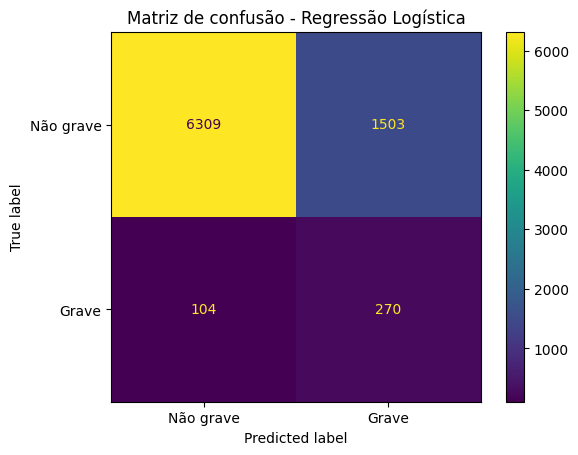

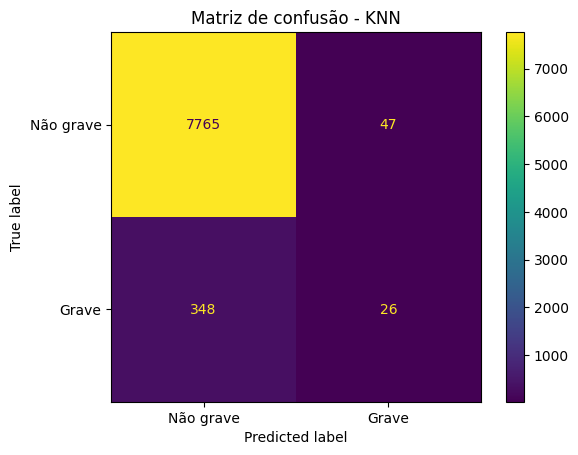

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_A, display_labels=['Não grave', 'Grave'])
plt.title('Matriz de confusão - Regressão Logística')
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, pred_B, display_labels=['Não grave', 'Grave'])
plt.title('Matriz de confusão - KNN')
plt.show()

### Lendo a matriz de confusão

Classe positiva: acidente fatal.

| Célula | Significado | Logística | KNN |
|---|---|---|---|
| TP | fatal que o modelo achou | 270 | 243 |
| FN | fatal que o modelo deixou passar | 104 | 131 |
| FP | alarme falso: não fatal marcado como grave | 1.503 | 1.373 |
| TN | não fatal corretamente liberado | 6.309 | 6.439 |

As métricas são contagens dessas células:

- Recall = TP / (TP + FN) = 270 / 374 = 0,722
- Precision = TP / (TP + FP) = 270 / 1.773 = 0,152
- Accuracy = (TP + TN) / total = 6.579 / 8.186 = 0,804

O FN é o erro que mais pesa: a Logística deixa passar 104 fatais, contra 131 do KNN.

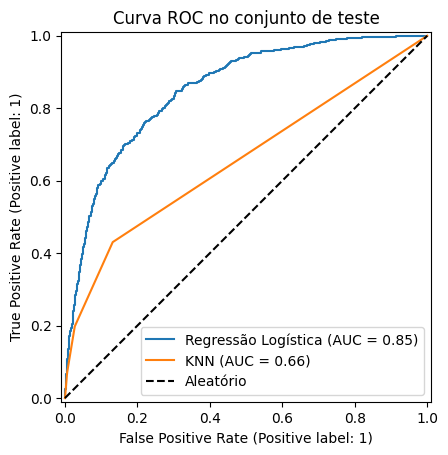

In [ ]:
# a terceira saída (limiares) não usamos
fpr_A, tpr_A, _ = roc_curve(y_test, prob_A)
fpr_B, tpr_B, _ = roc_curve(y_test, prob_B)

plt.plot(fpr_A, tpr_A, label='Regressão Logística')
plt.plot(fpr_B, tpr_B, label='KNN')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos (recall)')
plt.title('Curva ROC no conjunto de teste')
plt.legend()
plt.show()

In [ ]:
# o KNN demora aqui: compara cada linha com o treino inteiro
print("Regressão Logística: treino =", round(f1_score(y_train, modelo_A.predict(X_train)), 3),
      "| teste =", round(f1_score(y_test, pred_A), 3))
print("KNN: treino =", round(f1_score(y_train, modelo_B.predict(X_train)), 3),
      "| teste =", round(f1_score(y_test, pred_B), 3))

F1 da classe grave - treino x teste
Regressão Logística: treino = 0.258 | teste = 0.252
KNN:                 treino = 0.25 | teste = 0.116


In [ ]:
preprocessador_treinado = modelo_A.named_steps['pre']
regressao = modelo_A.named_steps['modelo']

nomes = preprocessador_treinado.get_feature_names_out()
pesos = regressao.coef_[0]

coeficientes = pd.Series(pesos, index=nomes).sort_values()

print("Atributos que mais AUMENTAM a chance de acidente grave:")
print(coeficientes.tail(5).round(2))
print()
print("Atributos que mais REDUZEM:")
print(coeficientes.head(5).round(2))

Atributos que mais AUMENTAM a chance de acidente grave:
cat__tracado_via_Curva;Declive                  0.77
cat__tracado_via_Reta;Declive                   0.87
cat__tipo_acidente_Eventos atípicos             0.94
cat__tipo_acidente_Colisão frontal              1.36
cat__tipo_acidente_Atropelamento de Pedestre    2.19
dtype: float64

Atributos que mais REDUZEM:
cat__tipo_acidente_Engavetamento                       -2.14
cat__tracado_via_Rotatória                             -1.08
cat__tipo_acidente_Colisão lateral mesmo sentido       -1.01
cat__causa_acidente_Ingestão de álcool pelo condutor   -0.94
cat__tracado_via_Interseção de Vias                    -0.90
dtype: float64


### Comparação no conjunto de teste

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Regressão Logística | 0,804 | 0,152 | 0,722 | 0,252 | 0,853 |
| KNN com subamostragem | 0,816 | 0,150 | 0,650 | 0,244 | 0,810 |

Dos 374 acidentes fatais de 2025, a Regressão Logística achou 270 e o KNN achou 243. A Logística vence nas duas métricas que escolhemos como principais, e a diferença maior está na curva ROC.

Sem balanceamento, o KNN achava só 26 dos 374, porque decidia pela maioria entre os vizinhos e quase nunca encontrava vizinhos graves. Equilibrar o treino resolveu esse problema.

### Sobreajuste

| Modelo | F1 treino | F1 teste |
|---|---|---|
| Regressão Logística | 0,258 | 0,252 |
| KNN com subamostragem | 0,253 | 0,244 |

Os dois se mantêm no teste. O KNN sem balanceamento caía de 0,250 para 0,116, ou seja, tinha decorado o treino.

### Importância dos atributos

Os maiores coeficientes positivos são atropelamento (+2,19) e colisão frontal (+1,36), o que confirma a EDA. Os mais negativos são engavetamento (-2,14) e rotatória (-1,08). Coeficiente mostra associação, não causa.

### Análise do limiar de decisão

A Regressão Logística devolve uma probabilidade, e o corte padrão para responder "grave" é 0,5. Mudar esse corte troca revocação por precisão. A curva abaixo é calculada **só com o treino**, usando as previsões de cada parte da validação cruzada.

In [ ]:
from sklearn.model_selection import cross_val_predict

# probabilidade que cada acidente recebeu quando estava na parte de avaliação
prob_treino = cross_val_predict(pipe_A.set_params(modelo__C=grid_A.best_params_['modelo__C']),
                                X_train, y_train, cv=cv,
                                method='predict_proba', n_jobs=-1)[:, 1]

cortes = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
revocacao, precisao, f1 = [], [], []
for corte in cortes:
    previsto = (prob_treino >= corte).astype(int)
    revocacao.append(recall_score(y_train, previsto))
    precisao.append(precision_score(y_train, previsto))
    f1.append(f1_score(y_train, previsto))
    print(f"corte {corte}: revocação={revocacao[-1]:.3f} precisão={precisao[-1]:.3f} f1={f1[-1]:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(cortes, revocacao, 'o-', label='Revocação')
plt.plot(cortes, precisao, 'o-', label='Precisão')
plt.plot(cortes, f1, 'o-', label='F1')
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Limiar usado (0,5)')
plt.xlabel('Limiar de decisão')
plt.ylabel('Valor da métrica')
plt.ylim(0, 1)
plt.legend()
plt.show()

O F1 é maior perto do corte 0,8, mas ali a revocação cai para menos da metade: o modelo deixaria passar metade dos acidentes fatais. Como a prioridade do trabalho é não deixar passar um acidente fatal, mantivemos o corte em 0,5.

Essa análise segue a recomendação de Fiorentini e Losa (2020), que defendem avaliar o desempenho classe por classe em vez de olhar só a acurácia.

## 13. Conclusão

O modelo escolhido é a Regressão Logística. Ela encontra 72% dos acidentes fatais de 2025, com ROC-AUC de 0,853, e se comporta igual no treino e no teste.

O problema prioriza não deixar passar um acidente fatal, por isso o Recall foi a métrica principal. O modelo deixou passar 104 dos 374 fatais (FN). O efeito colateral foi a Precision de 0,152, com 1.503 falsos positivos. O resultado supera o baseline, que tem 95,9% de Accuracy e Recall zero.

O KNN, depois de equilibrar o treino com subamostragem, chegou perto: 65% dos fatais e ROC-AUC de 0,810. A Logística ainda vence, e tem a vantagem de mostrar os pesos de cada variável.

A principal limitação é a precision de 0,152: de cada 100 alertas, uns 15 são acidentes realmente fatais. A análise do limiar mostra que dá para trocar isso por mais precisão, ao custo de deixar passar mais acidentes fatais.

O modelo serve para analisar acidentes já registrados, não para prever em tempo real, já que `pessoas` e `veiculos` só são conhecidas depois do acidente. Ele também só cobre rodovias federais e não tem dados de velocidade, cinto ou idade do veículo.

### Referências usadas nas decisões de método

- MAFORT, E. V.; KAPPEL, M. A. A. Técnicas de aprendizado de máquina para predição de gravidade de acidentes em rodovias do estado do Rio de Janeiro. **REIC**, v. 23, n. 1, p. 244-252, 2025.
- GABARDO, A. M. P. et al. Highway to... determining fatal outcomes in traffic accidents based on police reports. In: **BRACIS**, 35., 2025, Fortaleza. Anais. Porto Alegre: SBC, 2025. p. 230-244.
- SOUSA, G. I. L. de; RODRIGUES, M. C. de O.; ROSA, A. G. F. Aprendizado de máquina na análise de sinistros de trânsito: um estudo na zona urbana de Teresina - PI. **Scientia Generalis**, v. 7, n. 1, p. 1157-1175, 2026.
- FIORENTINI, N.; LOSA, M. Handling imbalanced data in road crash severity prediction by machine learning algorithms. **Infrastructures**, v. 5, n. 7, p. 61, 2020.

## 14. Especificações técnicas

In [ ]:
import sklearn, sys
print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
pandas: 2.2.3
numpy: 2.1.3
scikit-learn: 1.6.1
